# On data pre-processing

Each problem requires a different approach in what concerns data cleaning and preparation.
This pre-process can have a **deep impact on performance**; it can easily take a **significant amount of time**

1. Attribute coding (discretization, encoding)
2. Normalization (range, distribution)
3. Missing values (imputation)
4. Outliers
5. Feature selection
6. Feature extraction (feature engineering)
7. Dimensionality reduction and transformations


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


## 1. Discretization / encoding

In [20]:
import pandas as pd
import numpy as np

# Step 1: Create a toy dataset
data = {
    'Category': ['A', 'B', 'A', 'C', 'B', 'C', 'A', 'B'],
    'Value': [12.3, 23.4, 45.6, 56.7, 67.8, 78.9, 89.0, 90.1]
}

df = pd.DataFrame(data)

# Display the initial dataset
print("Initial Dataset:")
print(df)


Initial Dataset:
  Category  Value
0        A   12.3
1        B   23.4
2        A   45.6
3        C   56.7
4        B   67.8
5        C   78.9
6        A   89.0
7        B   90.1


In [21]:

df_encoded = pd.get_dummies(df, columns=['Category'], prefix=['Category'])

# Display the dataset after one-hot encoding
print("\nDataset after One-Hot Encoding:")
print(df_encoded)




Dataset after One-Hot Encoding:
   Value  Category_A  Category_B  Category_C
0   12.3        True       False       False
1   23.4       False        True       False
2   45.6        True       False       False
3   56.7       False       False        True
4   67.8       False        True       False
5   78.9       False       False        True
6   89.0        True       False       False
7   90.1       False        True       False


In [22]:


# Step 3: Discretize the continuous column into bins
# Let's discretize the 'Value' column into 3 bins: Low, Medium, High
#df_encoded['Value_bin'] = pd.cut(df_encoded['Value'], bins=3, labels=['Low', 'Medium', 'High'])

df_encoded["Value_bin"] = pd.cut(df_encoded["Value"], bins=3, labels=["Low", "Medium", "High"])


# Display the dataset after discretization
print("\nDataset after Discretization:")
print(df_encoded)




Dataset after Discretization:
   Value  Category_A  Category_B  Category_C Value_bin
0   12.3        True       False       False       Low
1   23.4       False        True       False       Low
2   45.6        True       False       False    Medium
3   56.7       False       False        True    Medium
4   67.8       False        True       False      High
5   78.9       False       False        True      High
6   89.0        True       False       False      High
7   90.1       False        True       False      High


In [23]:

# Optional: Drop the original 'Value' column if you only want to keep the discretized version
df_encoded = df_encoded.drop(columns=['Value'])

# Display the final dataset
print("\nFinal Dataset:")
print(df_encoded)


Final Dataset:
   Category_A  Category_B  Category_C Value_bin
0        True       False       False       Low
1       False        True       False       Low
2        True       False       False    Medium
3       False       False        True    Medium
4       False        True       False      High
5       False       False        True      High
6        True       False       False      High
7       False        True       False      High


## 2. Normalization

In [24]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Step 1: Create a toy dataset with a continuous column
data = {
    'Feature1': [10, 20, 30, 40, 50],
    'Feature2': [1, 2, 3, 4, 5],
    'Feature3': [-1, 2, -3, -4, 5]
}

df = pd.DataFrame(data)

# Display the initial dataset
print("Initial Dataset:")
print(df)



Initial Dataset:
   Feature1  Feature2  Feature3
0        10         1        -1
1        20         2         2
2        30         3        -3
3        40         4        -4
4        50         5         5


In [25]:

# Step 2: Normalize the continuous column using Min-Max Scaling (to [0, 1])
min_max_scaler = MinMaxScaler()
df['Feature1_minmax'] = min_max_scaler.fit_transform(df[['Feature1']])
df['Feature2_minmax'] = min_max_scaler.fit_transform(df[['Feature2']])
df['Feature3_minmax'] = min_max_scaler.fit_transform(df[['Feature3']])

# Display the dataset after Min-Max normalization
print("\nDataset after Min-Max Normalization:")
print(df)




Dataset after Min-Max Normalization:
   Feature1  Feature2  Feature3  Feature1_minmax  Feature2_minmax  \
0        10         1        -1             0.00             0.00   
1        20         2         2             0.25             0.25   
2        30         3        -3             0.50             0.50   
3        40         4        -4             0.75             0.75   
4        50         5         5             1.00             1.00   

   Feature3_minmax  
0         0.333333  
1         0.666667  
2         0.111111  
3         0.000000  
4         1.000000  


In [ ]:

# Step 3: Normalize the continuous column using Z-score Standardization (mean=0, std=1)
standard_scaler = StandardScaler()
df['Feature1_standard'] = standard_scaler.fit_transform(df[['Feature1']])
df['Feature2_standard'] = standard_scaler.fit_transform(df[['Feature2']])
df['Feature3_standard'] = standard_scaler.fit_transform(df[['Feature3']])

# Display the dataset after Z-score standardization
print("\nDataset after Z-score Standardization:")
print(df)

## 3. Imputation of missing values

Imputing missing values using a model-based sophisticated method involves using machine learning models to predict and fill in the missing values. This approach is more advanced than simple mean/median/mode imputation and can capture relationships between features to provide more accurate imputations.

A common model-based method is using k-Nearest Neighbors (k-NN) or regression models (e.g., linear regression, decision trees, or even more advanced models like Random Forests or Gradient Boosting). Below is an example using the KNNImputer from Scikit-learn, which is a popular model-based imputation method.

Check out the page for more sophisticated imputers from scikit-learn's page https://scikit-learn.org/stable/modules/impute.html

In [26]:
import pandas as pd
import numpy as np

# Step 1: Create a toy dataset with missing values
data = {
    'Feature1': [10, 20, np.nan, 40, 50],
    'Feature2': [1, np.nan, 3, 4, 5],
    'Feature3': [np.nan, 2, 3, np.nan, 5]
}

df = pd.DataFrame(data)

# Display the initial dataset with missing values
print("Initial Dataset with Missing Values:")
print(df)


Initial Dataset with Missing Values:
   Feature1  Feature2  Feature3
0      10.0       1.0       NaN
1      20.0       NaN       2.0
2       NaN       3.0       3.0
3      40.0       4.0       NaN
4      50.0       5.0       5.0


In [27]:

# Step 2: Impute missing values with the mean of the column
df_mean_imputed = df.fillna(df.mean())

# Display the dataset after mean imputation
print("\nDataset after Mean Imputation:")
print(df_mean_imputed)



Dataset after Mean Imputation:
   Feature1  Feature2  Feature3
0      10.0      1.00  3.333333
1      20.0      3.25  2.000000
2      30.0      3.00  3.000000
3      40.0      4.00  3.333333
4      50.0      5.00  5.000000


In [28]:

# Step 3: Impute missing values with the median of the column
df_median_imputed = df.fillna(df.median())

# Display the dataset after median imputation
print("\nDataset after Median Imputation:")
print(df_median_imputed)



Dataset after Median Imputation:
   Feature1  Feature2  Feature3
0      10.0       1.0       3.0
1      20.0       3.5       2.0
2      30.0       3.0       3.0
3      40.0       4.0       3.0
4      50.0       5.0       5.0


In [29]:

# Step 4: Impute missing values with a constant (e.g., 0)
df_constant_imputed = df.fillna(0)

# Display the dataset after constant imputation
print("\nDataset after Constant Imputation (0):")
print(df_constant_imputed)



Dataset after Constant Imputation (0):
   Feature1  Feature2  Feature3
0      10.0       1.0       0.0
1      20.0       0.0       2.0
2       0.0       3.0       3.0
3      40.0       4.0       0.0
4      50.0       5.0       5.0


In [30]:

# Step 5: Impute missing values with the mode of the column (most frequent value)
df_mode_imputed = df.fillna(df.mode().iloc[0])

# Display the dataset after mode imputation
print("\nDataset after Mode Imputation:")
print(df_mode_imputed)
# Step 5: Impute missing values with the mode of the column (most frequent value)
df_mode_imputed = df.fillna(df.mode().iloc[0])


Dataset after Mode Imputation:
   Feature1  Feature2  Feature3
0      10.0       1.0       2.0
1      20.0       1.0       2.0
2      10.0       3.0       3.0
3      40.0       4.0       2.0
4      50.0       5.0       5.0


The following example uses k-NN algorithm for imputation (we will see this in class when we do classification)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# Step 1: Create a toy dataset with missing values
data = {
    'Feature1': [10, 20, np.nan, 40, 50],
    'Feature2': [1, np.nan, 3, 4, 5],
    'Feature3': [np.nan, 2, 3, np.nan, 5]
}

df = pd.DataFrame(data)

# Display the initial dataset with missing values
print("Initial Dataset with Missing Values:")
print(df)

In [ ]:

# Step 2: Use KNNImputer to impute missing values
# The KNNImputer uses the k-nearest neighbors to fill in missing values
imputer = KNNImputer(n_neighbors=1)  # Use 1 nearest neighbors
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Display the dataset after KNN imputation
print("\nDataset after KNN Imputation:")
print(df_imputed)

## 4. Outlier detection

Finding outliers is an important step in data preprocessing for machine learning. Outliers are data points that deviate significantly from the rest of the data and can negatively impact the performance of machine learning models. There are several methods to detect outliers, including:

1. Statistical Methods:

    - __Z-score__: Identifies outliers based on how many standard deviations a data point is from the mean.
    - __IQR__ (Interquartile Range): Identifies outliers based on the spread of the middle 50% of the data.

2. Visual Methods:

    - __Boxplots__: Visualize the distribution of features of the data.
    - __Scatterplots__: Useful for identifying outliers in multivariate data.

3. Model-Based Methods:

    - __Isolation Forest__: An unsupervised algorithm that isolates outliers.
    - __DBSCAN__: A clustering algorithm that can identify outliers as noise.

Below is a Python script that demonstrates how to detect outliers using __Z-score__, and __IQR__.

In [31]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Step 1: Create a toy dataset with potential outliers
data = {
    'Feature1': [10, 12, 14, 1000, 15, 13, 11, 12, 14, 13],
    'Feature2': [1, 2, 3, 4, 5, 6, 7, 8, 9, 100]
}

df = pd.DataFrame(data)

# Display the initial dataset
print("Initial Dataset:")
print(df)


Initial Dataset:
   Feature1  Feature2
0        10         1
1        12         2
2        14         3
3      1000         4
4        15         5
5        13         6
6        11         7
7        12         8
8        14         9
9        13       100


In [32]:

# Step 2: Detect outliers using Z-score
# Z-score measures how many standard deviations a data point is from the mean
df['Z_score_Feature1'] = zscore(df['Feature1'])
df['Z_score_Feature2'] = zscore(df['Feature2'])

# Define outliers as data points with a Z-score greater than 3 or less than -3
df['Outlier_Z_Feature1'] = np.abs(df['Z_score_Feature1']) >= 3
df['Outlier_Z_Feature2'] = np.abs(df['Z_score_Feature2']) >= 3

print("\nDataset with Z-score Outlier Detection:")
print(df[['Feature1', 'Feature2', 'Z_score_Feature1', 'Outlier_Z_Feature1', 'Z_score_Feature2', 'Outlier_Z_Feature2']])



Dataset with Z-score Outlier Detection:
   Feature1  Feature2  Z_score_Feature1  Outlier_Z_Feature1  Z_score_Feature2  \
0        10         1         -0.342332               False         -0.471944   
1        12         2         -0.335580               False         -0.436985   
2        14         3         -0.328828               False         -0.402027   
3      1000         4          2.999966               False         -0.367068   
4        15         5         -0.325452               False         -0.332109   
5        13         6         -0.332204               False         -0.297150   
6        11         7         -0.338956               False         -0.262191   
7        12         8         -0.335580               False         -0.227232   
8        14         9         -0.328828               False         -0.192274   
9        13       100         -0.332204               False          2.988981   

   Outlier_Z_Feature2  
0               False  
1               Fal

In [33]:

# Step 3: Detect outliers using IQR (Interquartile Range)
Q1 = df[['Feature1', 'Feature2']].quantile(0.25)
Q3 = df[['Feature1', 'Feature2']].quantile(0.75)
IQR = Q3 - Q1

# Define outliers as data points outside 1.5 * IQR from Q1 and Q3
df['Outlier_IQR_Feature1'] = (df['Feature1'] < (Q1['Feature1'] - 1.5 * IQR['Feature1'])) | (df['Feature1'] > (Q3['Feature1'] + 1.5 * IQR['Feature1']))
df['Outlier_IQR_Feature2'] = (df['Feature2'] < (Q1['Feature2'] - 1.5 * IQR['Feature2'])) | (df['Feature2'] > (Q3['Feature2'] + 1.5 * IQR['Feature2']))

print("\nDataset with IQR Outlier Detection:")
print(df[['Feature1', 'Feature2', 'Outlier_IQR_Feature1', 'Outlier_IQR_Feature2']])



Dataset with IQR Outlier Detection:
   Feature1  Feature2  Outlier_IQR_Feature1  Outlier_IQR_Feature2
0        10         1                 False                 False
1        12         2                 False                 False
2        14         3                 False                 False
3      1000         4                  True                 False
4        15         5                 False                 False
5        13         6                 False                 False
6        11         7                 False                 False
7        12         8                 False                 False
8        14         9                 False                 False
9        13       100                 False                  True


## 5. Feature selection

We will cover this in more detail in a future lab session.

## 6. Feature extraction (feature engineering)

Feature engineering is the process of creating new features or transforming existing ones to improve the performance of machine learning models. 
Below is a Python exammple that creates a toy dataset where feature engineering can significantly improve model performance. 
The dataset simulates a scenario where raw features are not directly useful, but engineered features (e.g., interactions, transformations, or aggregations) can reveal meaningful patterns.

In general, this is a very domain-specific task that requires human knowledge, so it is _hard to automate_.

### Toy Dataset: Predicting House Prices

In this example, we create a dataset where:

- The target variable (`Price`) depends on __non-linear relationships__ and __interactions__ between features.
- Raw features (`Size`, `Rooms`, `Age`) are not directly useful, but engineered features (e.g., `Size per Room`, `Age squared`) can improve model performance.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Create a toy dataset
np.random.seed(42)
n_samples = 1000

# Raw features
size = np.random.uniform(500, 3000, n_samples)  # Size of the house in sq. ft.
rooms = np.random.randint(1, 6, n_samples)     # Number of rooms
age = np.random.randint(0, 100, n_samples)      # Age of the house in years

# Simulate the target variable (Price) with non-linear relationships and interactions
price = (
    100 * (size / rooms)  # Price increases with size per room
    - 50 * (age ** 0.5)   # Price decreases with the square root of age
    + np.random.normal(0, 5000, n_samples)  # Add some noise
)

# Create a DataFrame
df = pd.DataFrame({
    'Size': size,
    'Rooms': rooms,
    'Age': age,
    'Price': price
})

# Display the first few rows of the dataset
print("Raw Dataset:")
print(df.head())


In [ ]:

# Step 2: Feature Engineering
# Create new features that capture non-linear relationships and interactions
df['Size_per_Room'] = df['Size'] / df['Rooms']  # Size per room
df['Age_squared'] = df['Age'] ** 0.5            # Square root of age
df['Size_Age_Interaction'] = df['Size'] * df['Age_squared']  # Interaction between size and age

# Display the dataset with engineered features
print("\nDataset with Engineered Features:")
print(df.head())


In [ ]:

# Step 3: Compare raw vs engineered features
# Check correlation of raw and engineered features with the target variable
correlation = df.corr()['Price'].sort_values(ascending=False)
print("\nCorrelation with Target (Price):")
print(correlation)

In [ ]:
import warnings

# Suppress warnings from seaborn
warnings.filterwarnings('ignore', module='seaborn')

# Step 4: Plot pair-wise scatterplots to visually show correlations
sns.pairplot(df, diag_kind='kde', height=1.5, aspect=1);

# Add a title
plt.suptitle("Pairwise Scatterplots of Features", y=1.02);


## 7. Dimensionality reduction and transformations


Dimensionality reduction is a technique used to reduce the number of features in a dataset while preserving as much information as possible. 

__Principal Component Analysis (PCA)__ is one of the most popular dimensionality reduction techniques. Below is a Python script that creates a toy dataset and demonstrates how to apply PCA for dimensionality reduction.

More on this and other __non-linear dimensionality reduction techniques__ in upcoming lab sessions.

In [34]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Step 1: Create a toy dataset
np.random.seed(42)
n_samples = 300

# Generate random data for 2 features
feature1 = np.random.normal(0, 1, n_samples)
feature2 = np.random.normal(0, 1, n_samples)

# Create a third feature as a linear combination of the first two
feature3 = 0.5 * feature1 + 0.5 * feature2 + np.random.normal(0, 0.1, n_samples)  # Add some noise

# Combine into a DataFrame
df = pd.DataFrame({
    'Feature1': feature1,
    'Feature2': feature2,
    'Feature3': feature3
})

# Display the first few rows of the dataset
print("Toy Dataset:")
print(df.head())


Toy Dataset:
   Feature1  Feature2  Feature3
0  0.496714 -0.828995 -0.090442
1 -0.138264 -0.560181 -0.441439
2  0.647689  0.747294  0.784452
3  1.523030  0.610370  1.202264
4 -0.234153 -0.020902 -0.086184


In [35]:

# Step 2: Standardize the data (PCA is sensitive to the scale of the features)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Step 3: Apply PCA to reduce the dataset to 2 dimensions
pca = PCA(n_components=2)  # Reduce to 2 dimensions
df_pca = pca.fit_transform(df_scaled)

# Convert the result to a DataFrame for better visualization
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

# Display the first few rows of the transformed dataset
print("\nDataset after PCA:")
print(df_pca.head())



Dataset after PCA:
        PC1       PC2
0 -0.244601 -0.959096
1 -0.803176 -0.307809
2  1.559878  0.109764
3  2.378832 -0.614007
4 -0.201892  0.162848


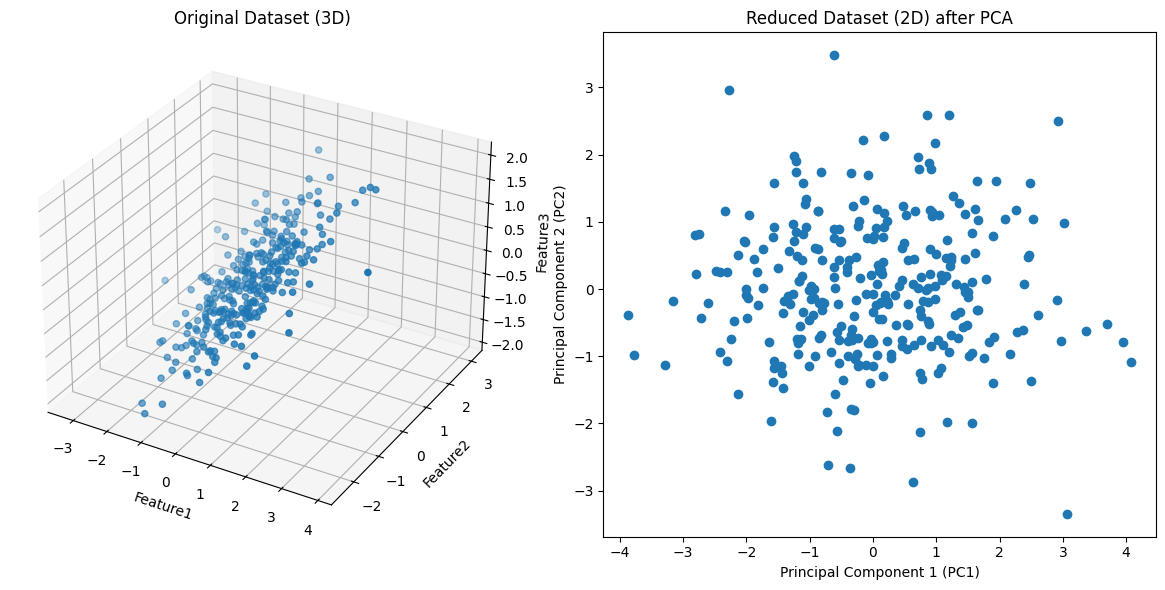

In [36]:

# Step 4: Visualize the original and reduced datasets
plt.figure(figsize=(12, 6))

# Plot the original dataset (3D)
ax1 = plt.subplot(1, 2, 1, projection='3d')
ax1.scatter(df['Feature1'], df['Feature2'], df['Feature3'])
ax1.set_title("Original Dataset (3D)")
ax1.set_xlabel("Feature1")
ax1.set_ylabel("Feature2")
ax1.set_zlabel("Feature3")

# Plot the reduced dataset (2D)
plt.subplot(1, 2, 2)
plt.scatter(df_pca['PC1'], df_pca['PC2'])
plt.title("Reduced Dataset (2D) after PCA")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

plt.tight_layout()
plt.show()


In [37]:

# Step 5: Explain the variance captured by each principal component
explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance by Each Principal Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.2%}")


Explained Variance by Each Principal Component:
PC1: 64.96%
PC2: 34.68%
